# Number of shots a team will take in an upcoming match

In [1]:
### Important libraries

from final_presentation import ShotPredictor
import pandas as pd

%load_ext autoreload
%autoreload 2

In [2]:
### Run this to call the class, might take a while to run, once run dont need to run again until you close the file

sp = ShotPredictor()

[PreparePastData] Dropped 2 rows with missing team or shot data.

[PreparePastData] 5 rows are missing odds:
      date home_team   away_team  league season
2020-10-18   Udinese       Parma serie_a   2021
2020-10-19    Verona       Genoa serie_a   2021
2022-01-10    Torino  Fiorentina serie_a   2122
2020-09-13  Paris SG   Marseille ligue_1   2021
2020-10-18    Monaco Montpellier ligue_1   2021

Use patch_odds() to manually supply odds for any of these.

[PreparePastData] Re-applied 4 manual patch(es) from manual_odds_patches.json.
  [Odds API] premier_league: 10 matches fetched
  [Odds API] bundesliga: 1 matches fetched
  [Odds API] la_liga: 10 matches fetched
  [Odds API] serie_a: 10 matches fetched
  [Odds API] ligue_1: 1 matches fetched

[PreparePastData] 2 future match(es) dropped — team name(s) not in name map.
  Run pp.review_team_names() to resolve missing mappings.



## Some notes

 
- It should not be a past date, it will only work for matches happening currently or matches which will happen in the future
- All the matches might not be available, the closer the match is to the current date, the more likely it is to be available.
- Matches early in the season are less likely to be available, as the data is updated after the match is played.
- Please be careful of the date format, it is in "YYYY-MM-DD" format
- The team names may not exactly match the team, for example West Ham United may be West Ham

In [9]:
date = '2026-05-22' # date of the match 
team = "Fiorentina"   #The team playing on the date

In [8]:
### Check all the matches happening on the date, and the teams playing in those matches 
### Useful to find the correct team name

sp.matches_on_date(date)

               date  league  home_team away_team
2026-05-22 19:45:00 serie_a Fiorentina  Atalanta


,date,league,home_team,away_team
0,2026-05-22 19:45:00,serie_a,Fiorentina,Atalanta


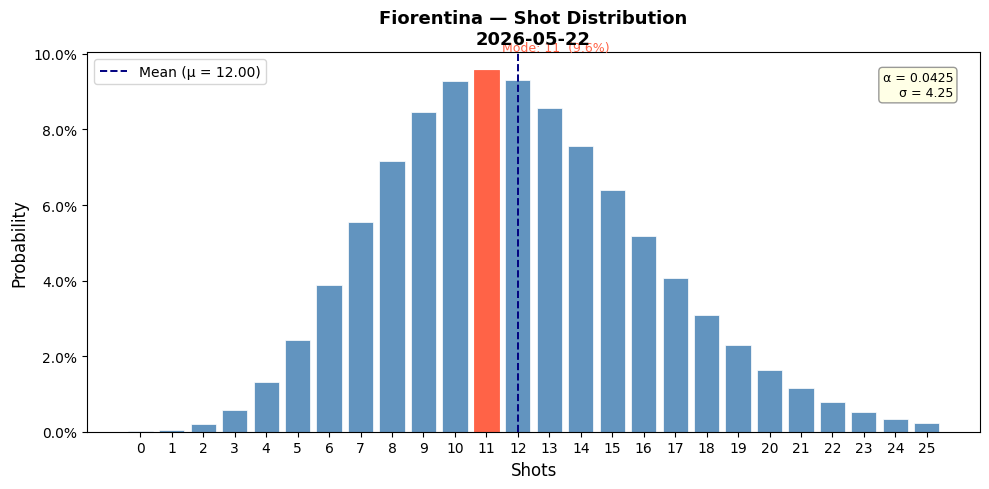

In [10]:
### Provides a graph to visualise the odds of the number of shots the team takes in the match

sp.plot(date, team)

- If you want to see the best bet for the match, you can use the following code
- The odds are in the format {number of shots: odds}, where the odds represents the payout if there are at least that many shots for the team in the match. Odds given by Betway in this format.
- The table displays if any of the given odds are underpriced based on the model.

In [12]:
odds = {7: 51/50, 8: 26/25, 9: 15/14, 10: 8/7, 11: 5/4, 12: 7/5, 13: 11/7, 14: 11/6, 15: 11/5, 16: 21/8, 17: 13/4, 18: 4/1, 19: 5, 20: 7, 21: 9, 22: 12, 23: 15, 24: 17, 25: 17}


sp.betway_best_bet(date, team, odds)


  Fiorentina  |  2026-05-22
  μ = 12.00  |  α = 0.0425
threshold      odds  market_prob  model_prob    edge  half_kelly
       7+  1.020000       0.9804      0.9118 -0.0686           0
       8+  1.040000       0.9615      0.8563 -0.1052           0
       9+  1.071429       0.9333      0.7848 -0.1486           0
      10+  1.142857       0.8750      0.7001 -0.1749           0
      11+  1.250000       0.8000      0.6072 -0.1928           0
      12+  1.400000       0.7143      0.5115 -0.2028           0
      13+  1.571429       0.6364      0.4185 -0.2179           0
      14+  1.833333       0.5455      0.3327 -0.2128           0
      15+  2.200000       0.4545      0.2571 -0.1975           0
      16+  2.625000       0.3810      0.1932 -0.1877           0
      17+  3.250000       0.3077      0.1413 -0.1664           0
      18+  4.000000       0.2500      0.1005 -0.1495           0
      19+  5.000000       0.2000      0.0695 -0.1305           0
      20+  7.000000       0.1429  

,threshold,odds,market_prob,model_prob,edge,half_kelly
0,7+,1.020000,0.9804,0.9118,-0.0686,0
1,8+,1.040000,0.9615,0.8563,-0.1052,0
2,9+,1.071429,0.9333,0.7848,-0.1486,0
3,10+,1.142857,0.8750,0.7001,-0.1749,0
4,11+,1.250000,0.8000,0.6072,-0.1928,0
5,12+,1.400000,0.7143,0.5115,-0.2028,0
6,13+,1.571429,0.6364,0.4185,-0.2179,0
7,14+,1.833333,0.5455,0.3327,-0.2128,0
8,15+,2.200000,0.4545,0.2571,-0.1975,0
9,16+,2.625000,0.3810,0.1932,-0.1877,0
